In [200]:
import pandas as pd
import mne
import pyxdf
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path

## Load EEG files

In [201]:
# Find and read 0-back annotated EEG FIF files
repo_root = Path.cwd()
while not (repo_root / "data").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

annot_dir = repo_root / "data" / "2-back" / "eeg"
annot_files = sorted(annot_dir.rglob("*_annot_raw.fif"))

print(f"Annotated directory: {annot_dir}")
print(f"Found {len(annot_files)} annotated files")
for f in annot_files:
    print("-", f.relative_to(repo_root))

# Load all files into memory (keyed by subject ID)
raw_annot_by_subject = {}
for f in annot_files:
    match = re.search(r"sub-(P\d+)", f.name)
    subj = match.group(1) if match else f.stem
    raw_annot_by_subject[subj] = mne.io.read_raw_fif(f, preload=False, verbose="ERROR")

print(f"Loaded {len(raw_annot_by_subject)} Raw objects")
print("Subjects:", sorted(raw_annot_by_subject.keys()))

# Quick peek at one recording
if raw_annot_by_subject:
    first_subj = sorted(raw_annot_by_subject.keys())[1]
    display(raw_annot_by_subject[first_subj])

Annotated directory: c:\Users\n.saleem\Documents\GitHub\0x2x2dual_WCST_analysis\data\2-back\eeg
Found 4 annotated files
- data\2-back\eeg\sub-P001\ses-S001\eeg\sub-P001_ses-S001_task-Default_run-001_eeg_annot_raw.fif
- data\2-back\eeg\sub-P002\ses-S001\eeg\sub-P002_ses-S001_task-Default_run-001_eeg_annot_raw.fif
- data\2-back\eeg\sub-P003\ses-S001\eeg\sub-P003_ses-S001_task-Default_run-001_eeg_annot_raw.fif
- data\2-back\eeg\sub-P004\ses-S001\eeg\sub-P004_ses-S001_task-Default_run-001_eeg_annot_raw.fif
Loaded 4 Raw objects
Subjects: ['P001', 'P002', 'P003', 'P004']


<Raw | sub-P002_ses-S001_task-Default_run-001_eeg_annot_raw.fif, 20 x 1033970 (2067.9 s), ~30 KiB, data not loaded>

## Downsample all annotated EEG files

In [202]:
# Downsample all loaded subjects to a common sampling frequency
target_sfreq = 250  # Hz

raw_ds_by_subject = {}
summary_rows = []

for subj, raw in sorted(raw_annot_by_subject.items()):
    original_sfreq = float(raw.info["sfreq"])
    # raw.copy().load_data() is required because resampling needs data in memory
    raw_ds = raw.copy().load_data().resample(sfreq=target_sfreq, npad="auto")
    raw_ds_by_subject[subj] = raw_ds

    summary_rows.append({
        "subject": subj,
        "original_sfreq": original_sfreq,
        "downsampled_sfreq": float(raw_ds.info["sfreq"]),
        "n_samples_after": raw_ds.n_times
    })

downsample_summary = pd.DataFrame(summary_rows)
display(downsample_summary)
print(f"Downsampled {len(raw_ds_by_subject)} subjects to {target_sfreq} Hz")

Reading 0 ... 917458  =      0.000 ...  1834.916 secs...


Reading 0 ... 1033969  =      0.000 ...  2067.938 secs...
Reading 0 ... 950474  =      0.000 ...  1900.948 secs...
Reading 0 ... 941717  =      0.000 ...  1883.434 secs...


,subject,original_sfreq,downsampled_sfreq,n_samples_after
0,P001,500.0,250.0,458730
1,P002,500.0,250.0,516985
2,P003,500.0,250.0,475238
3,P004,500.0,250.0,470859


Downsampled 4 subjects to 250 Hz


### Plot one subject (downsampled raw)

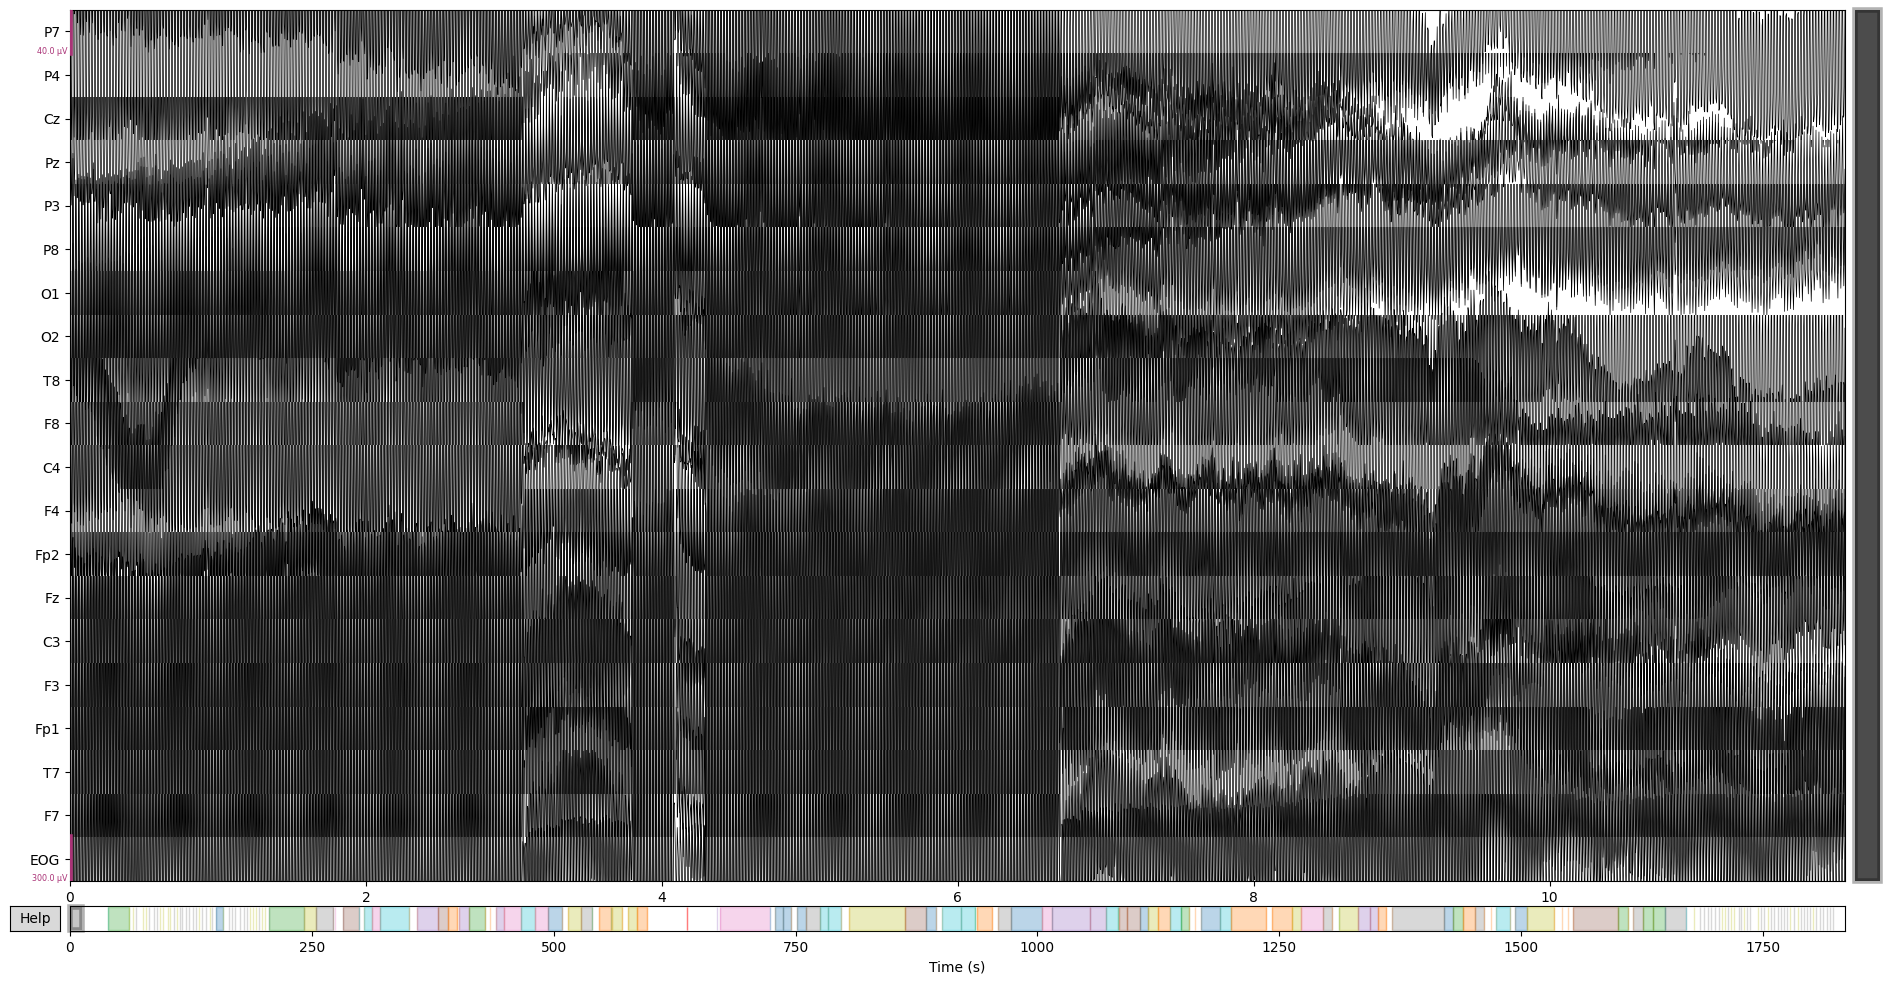

In [203]:
subject_to_plot = "P001"

raw_plot = raw_ds_by_subject[subject_to_plot]

raw_plot.plot(
    duration=12,
    n_channels=20,
    show=True,
);

## bp filter 1 - 40 hz

In [204]:
# Apply band-pass filter to all downsampled subjects
l_freq = 1.0
h_freq = 40.0

if "raw_ds_by_subject" not in globals() or not raw_ds_by_subject:
    raise RuntimeError("Run the downsampling cell first.")

raw_bp_by_subject = {}
filter_summary_rows = []

for subj, raw in sorted(raw_ds_by_subject.items()):
    raw_bp = raw.copy().filter(
        l_freq=l_freq,
        h_freq=h_freq,
        fir_design="firwin",
        verbose="ERROR"
    )
    raw_bp_by_subject[subj] = raw_bp

    filter_summary_rows.append({
        "subject": subj,
        "sfreq": float(raw_bp.info["sfreq"]),
        "l_freq": l_freq,
        "h_freq": h_freq,
        "n_samples": raw_bp.n_times
    })

filter_summary = pd.DataFrame(filter_summary_rows)
display(filter_summary)

,subject,sfreq,l_freq,h_freq,n_samples
0,P001,250.0,1.0,40.0,458730
1,P002,250.0,1.0,40.0,516985
2,P003,250.0,1.0,40.0,475238
3,P004,250.0,1.0,40.0,470859


### Plot after bp filter

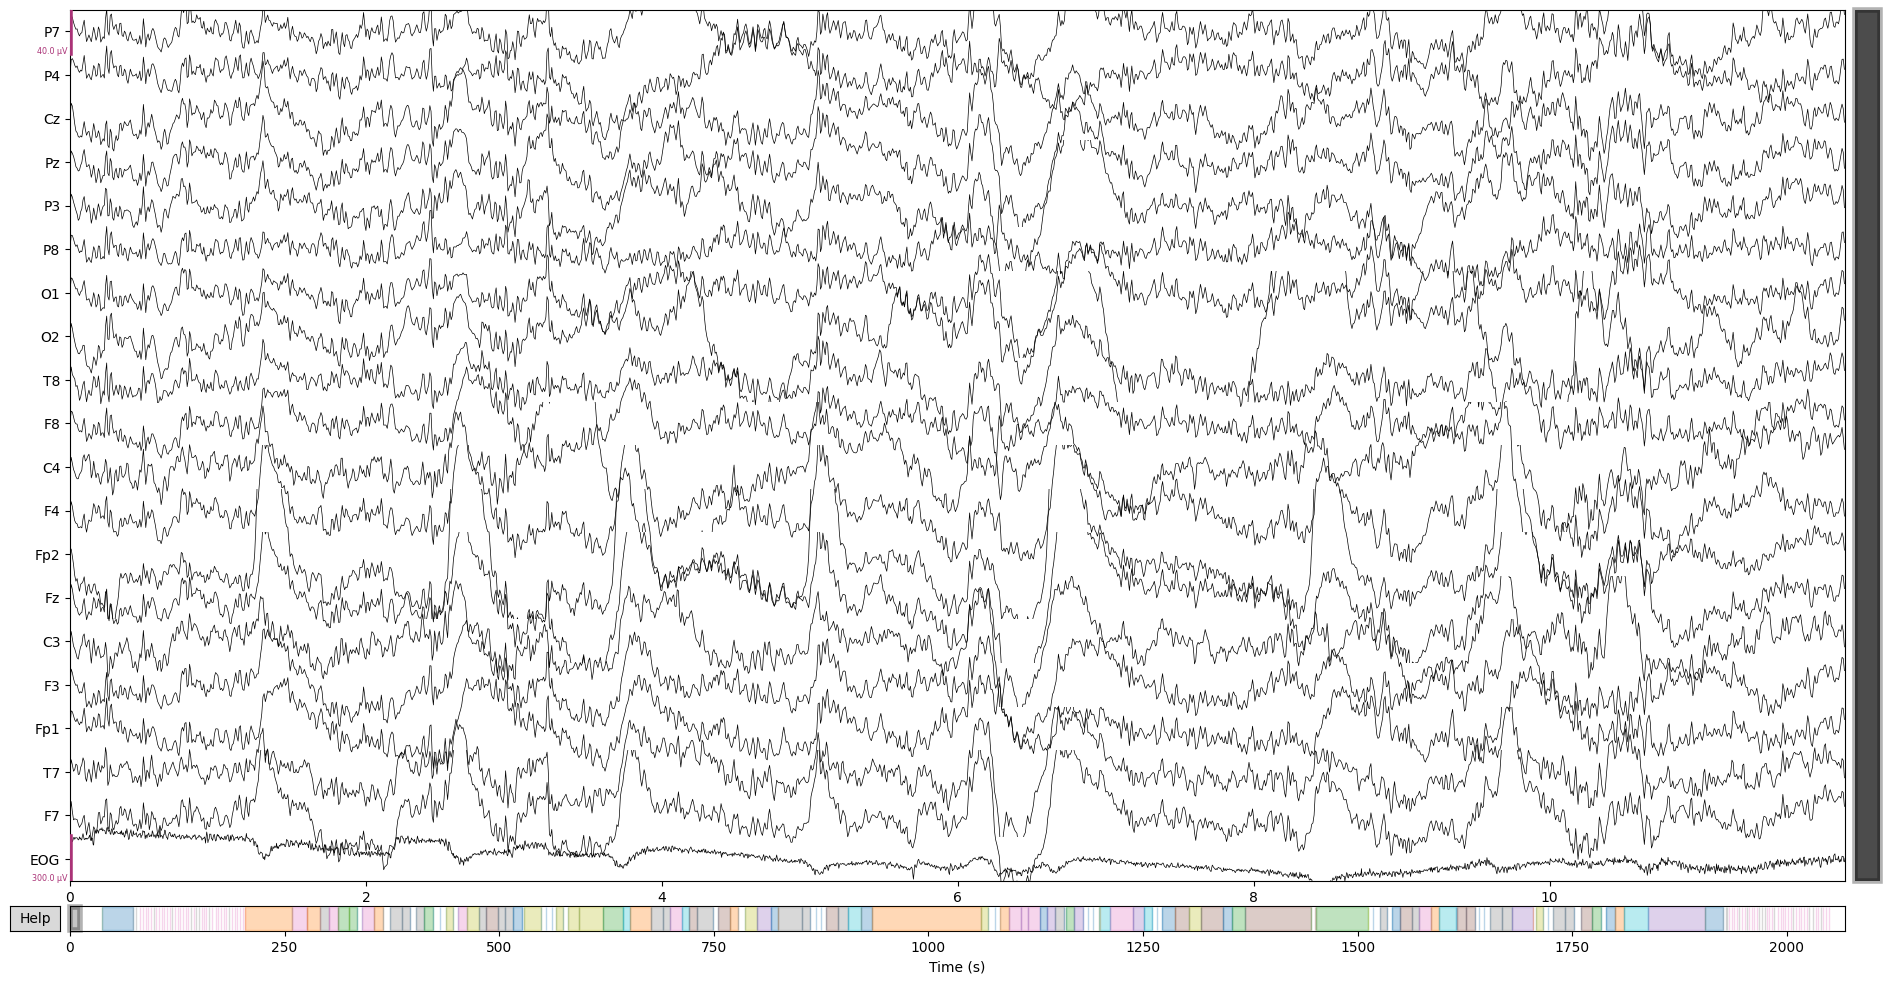

In [205]:
subject_to_plot_bp = "P002"

available_subjects_bp = sorted(raw_bp_by_subject.keys())
raw_bp_plot = raw_bp_by_subject[subject_to_plot_bp]
raw_bp_plot.plot(
    duration=12,
    n_channels=20,
    show=True,
);

## Spectrum per subject for two manual time intervals

Selected electrodes: ['P7', 'P4', 'Cz', 'Pz', 'P3', 'P8', 'O1', 'O2', 'T8', 'C4', 'F4', 'Fp2', 'Fz', 'C3', 'Fp1', 'T7', 'F7']


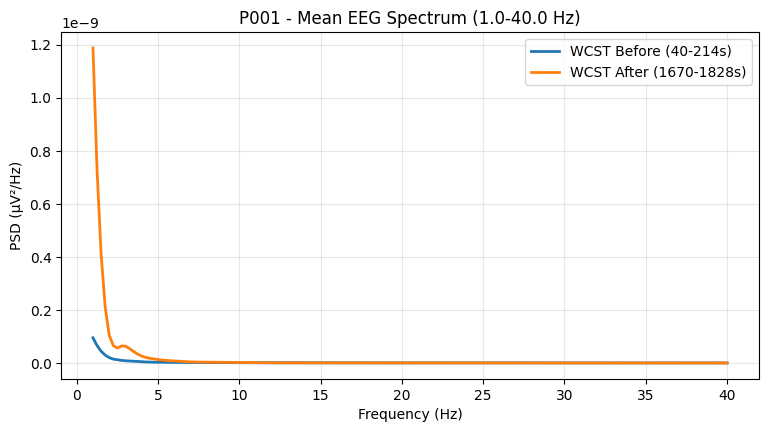

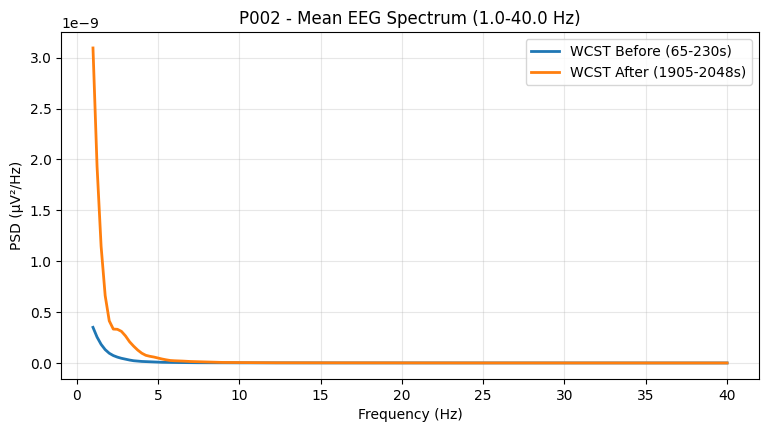

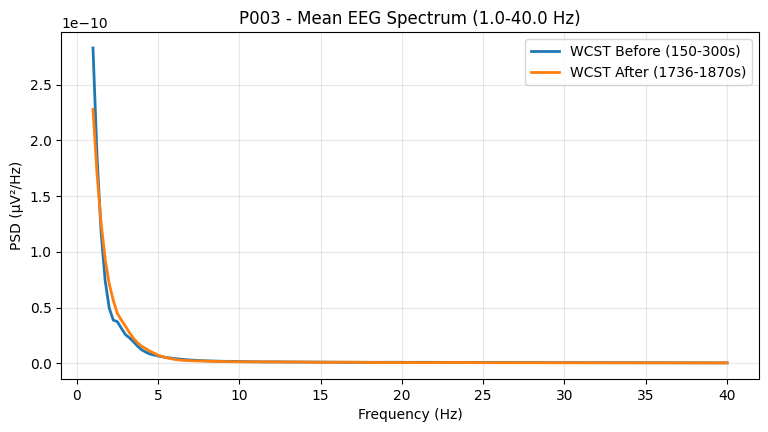

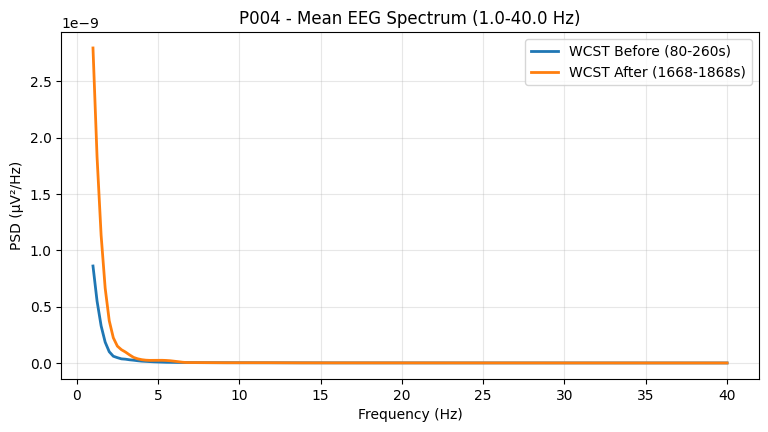

In [207]:
manual_intervals_by_subject = {
    "P001": {"WCST Before": (40, 214), "WCST After": (1670, 1828)},
    "P002": {"WCST Before": (65, 230), "WCST After": (1905, 2048)},
    "P003": {"WCST Before": (150, 300), "WCST After": (1736, 1870)},
    "P004": {"WCST Before": (80, 260), "WCST After": (1668, 1868)},
}

# Use all EEG electrodes except T7 and F8
exclude_electrodes_for_spectrum = {"F3", "F8"}

first_raw = next(iter(raw_bp_by_subject.values()))
all_eeg_channels = [first_raw.ch_names[idx] for idx in mne.pick_types(first_raw.info, eeg=True, meg=False)]

selected_electrodes_for_spectrum = [ch for ch in all_eeg_channels if ch not in exclude_electrodes_for_spectrum]
print("Selected electrodes:", selected_electrodes_for_spectrum)

fmin, fmax = 1.0, 40.0
spectrum_results = {}

# Welch parameters for smooth, less noisy spectra
sfreq = 250
n_fft = int(sfreq * 4)  # 4-second windows for smoothing
n_overlap = n_fft // 2  # 50% overlap

for subj, raw in sorted(raw_bp_by_subject.items()):
    if subj not in manual_intervals_by_subject:
        raise ValueError(f"Missing intervals for {subj} in manual_intervals_by_subject")

    subject_intervals = manual_intervals_by_subject[subj]
    max_time = raw.times[-1]
    spectrum_results[subj] = {}

    available_eeg_channels = [raw.ch_names[idx] for idx in mne.pick_types(raw.info, eeg=True, meg=False)]
    if selected_electrodes_for_spectrum:
        missing_electrodes = [ch for ch in selected_electrodes_for_spectrum if ch not in available_eeg_channels]
        if missing_electrodes:
            raise ValueError(
                f"These electrodes are not available for {subj}: {missing_electrodes}. "
                f"Available electrodes: {available_eeg_channels}"
            )
        picks = selected_electrodes_for_spectrum
    else:
        picks = "eeg"

    fig, ax = plt.subplots(figsize=(9, 4.5))

    for cond_name, (tmin, tmax) in subject_intervals.items():
        if tmin < 0 or tmax <= tmin or tmax > max_time:
            raise ValueError(
                f"Invalid interval for {subj} - {cond_name}: ({tmin}, {tmax}), max_time={max_time:.2f}s"
            )

        psd = raw.compute_psd(
            method="welch",
            fmin=fmin,
            fmax=fmax,
            tmin=tmin,
            tmax=tmax,
            n_fft=n_fft,
            n_overlap=n_overlap,
            picks=picks,
            verbose="ERROR"
        )
        freqs = psd.freqs
        psd_data = psd.get_data()  # shape: (n_channels, n_freqs)
        mean_psd = psd_data.mean(axis=0)
        ch_names = psd.ch_names

        # Apply smoothing to reduce noise (Savitzky-Golay filter)
        from scipy.signal import savgol_filter
        window_length = min(11, len(mean_psd) if len(mean_psd) % 2 == 1 else len(mean_psd) - 1)
        if window_length >= 5:
            mean_psd_smooth = savgol_filter(mean_psd, window_length, polyorder=3)
            psd_data_smooth = np.array([savgol_filter(psd_data[i], window_length, polyorder=3)
                                       for i in range(psd_data.shape[0])])
        else:
            mean_psd_smooth = mean_psd
            psd_data_smooth = psd_data

        spectrum_results[subj][cond_name] = {
            "freqs": freqs,
            "mean_psd": mean_psd_smooth,
            "psd_data": psd_data_smooth,
            "ch_names": ch_names,
            "interval": (tmin, tmax),
        }

        ax.plot(freqs, mean_psd_smooth, label=f"{cond_name} ({tmin}-{tmax}s)", linewidth=2)

    ax.set_title(f"{subj} - Mean EEG Spectrum ({fmin}-{fmax} Hz)")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD (μV²/Hz)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

## Spectrum per single frequency band across all electrodes

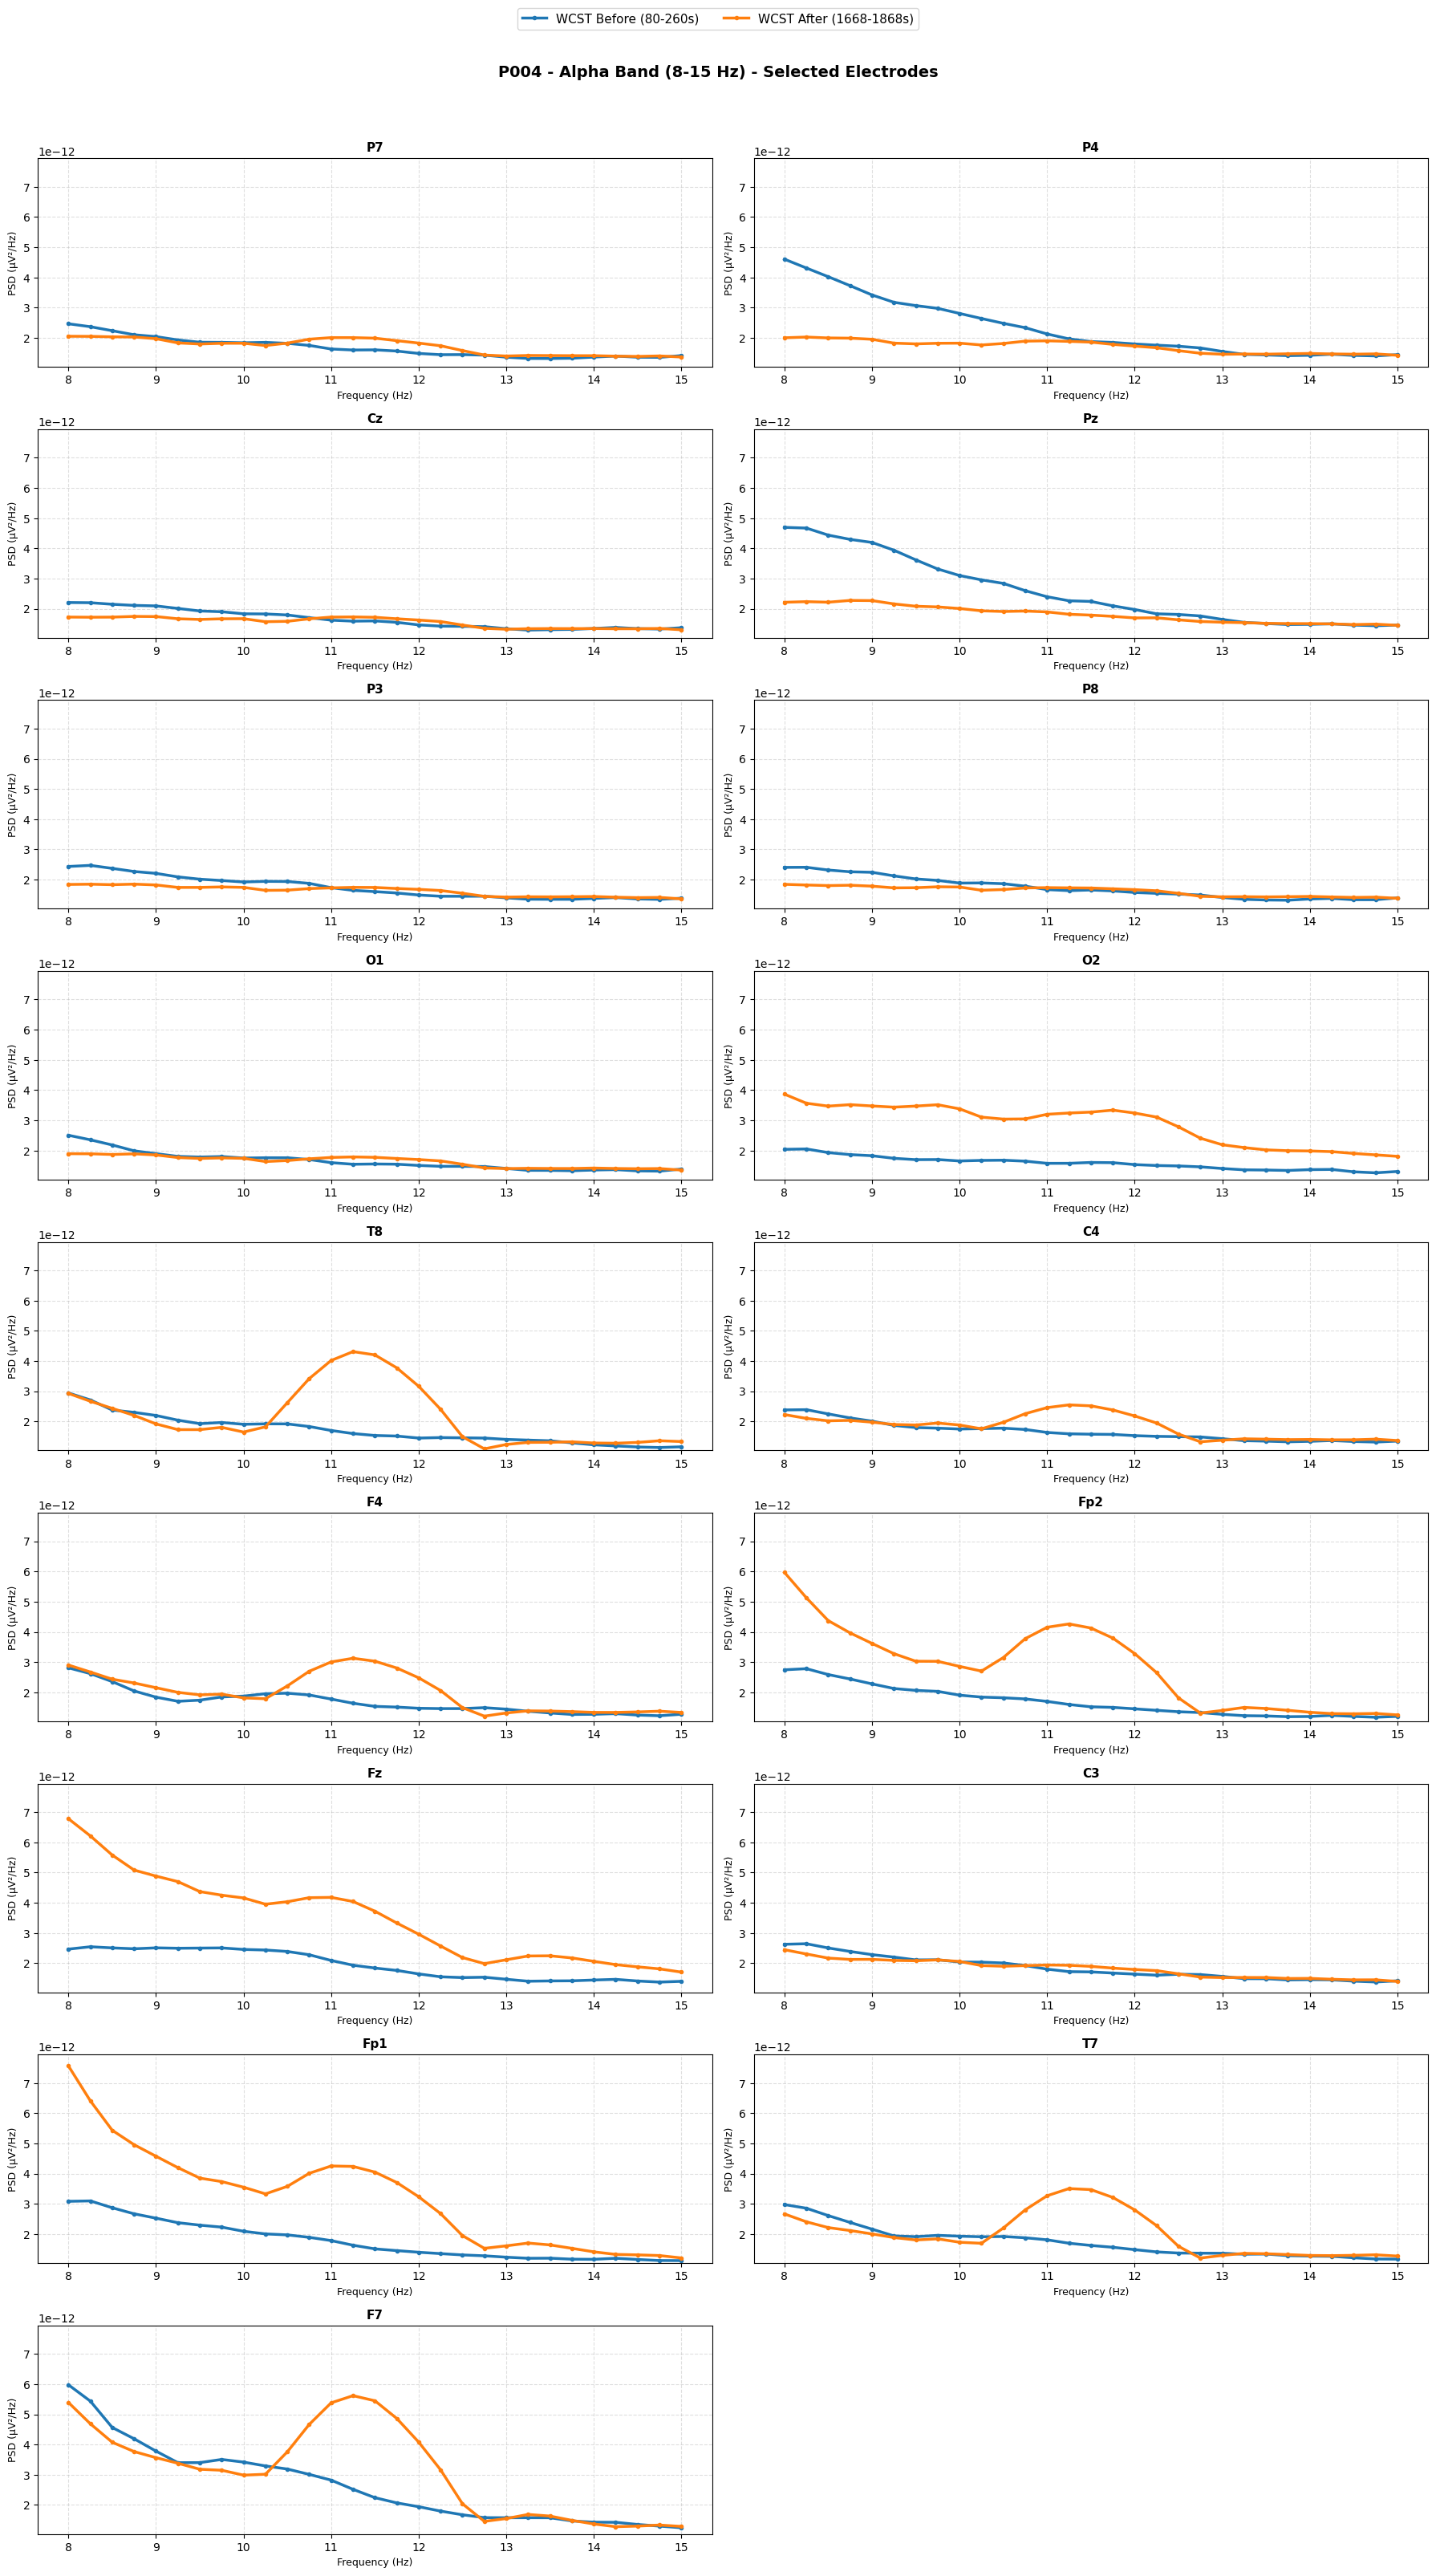

In [213]:
# Define frequency bands with your specifications
freq_bands = {
    "Delta": (0.1, 3),
    "Theta": (4, 7),
    "Alpha": (8, 15),
    "Beta": (16, 30),
    "Theta+Alpha": (4, 15),
    "Alpha+Beta": (8, 30),
    "Delta+Theta": (0.1, 7),
    "All": (4, 30)
}

# Select which band to plot
selected_band = "Alpha"  # Change to any band name above
subject_for_band = "P004"  # Change to P002/P003/P004 as needed
selected_electrodes = selected_electrodes_for_spectrum

if selected_band not in freq_bands:
    available = ", ".join(list(freq_bands.keys()))
    raise ValueError(f"Invalid band '{selected_band}'. Choose one of: {available}")

band_range = freq_bands[selected_band]
subject_data = spectrum_results[subject_for_band]

# Get first condition to determine available channels from Cell 13 results
first_cond = list(subject_data.keys())[0]
all_ch_names = subject_data[first_cond]["ch_names"]

if selected_electrodes:
    missing_electrodes = [ch for ch in selected_electrodes if ch not in all_ch_names]
    if missing_electrodes:
        raise ValueError(
            f"These electrodes are not available for {subject_for_band}: {missing_electrodes}. "
            f"Available electrodes from Cell 13: {all_ch_names}"
        )
    selected_indices = [all_ch_names.index(ch) for ch in selected_electrodes]
    ch_names = selected_electrodes
else:
    selected_indices = list(range(len(all_ch_names)))
    ch_names = all_ch_names

n_channels = len(selected_indices)

# FIRST PASS: Calculate global min/max across selected electrodes and conditions for this band
all_band_psd_values = []
for cond_name, cond_data in subject_data.items():
    freqs = cond_data["freqs"]
    psd_data = cond_data["psd_data"]

    # Mask to only show frequencies within the selected band
    band_mask = (freqs >= band_range[0]) & (freqs <= band_range[1])

    for ch_idx in selected_indices:
        psd_ch = psd_data[ch_idx]
        band_psd = psd_ch[band_mask]
        all_band_psd_values.extend(band_psd)

# Calculate unified y-axis limits for selected electrodes
band_global_min = min(all_band_psd_values)
band_global_max = max(all_band_psd_values)
ylim_all_electrodes = (band_global_min * 0.95, band_global_max * 1.05)  # 5% padding

n_cols = 2
n_rows = (n_channels + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for plot_idx, ch_idx in enumerate(selected_indices):
    ch_name = all_ch_names[ch_idx]
    ax = axes[plot_idx]

    # Plot both conditions for this band
    for cond_name, cond_data in subject_data.items():
        freqs = cond_data["freqs"]
        psd_ch = cond_data["psd_data"][ch_idx]
        interval = cond_data["interval"]

        # Mask to only show frequencies within the selected band
        band_mask = (freqs >= band_range[0]) & (freqs <= band_range[1])
        band_freqs = freqs[band_mask]
        band_psd = psd_ch[band_mask]

        ax.plot(band_freqs, band_psd, label=f"{cond_name} ({interval[0]}-{interval[1]}s)",
                linewidth=2.5, marker="o", markersize=3)

    ax.set_title(ch_name, fontsize=11, fontweight="bold")
    ax.set_ylim(ylim_all_electrodes)  # UNIFIED SCALE
    ax.grid(True, alpha=0.4, linestyle="--")
    ax.set_ylabel("PSD (μV²/Hz)", fontsize=9)
    ax.set_xlabel("Frequency (Hz)", fontsize=9)

# Remove empty subplots
for plot_idx in range(n_channels, len(axes)):
    fig.delaxes(axes[plot_idx])

fig.legend(axes[0].get_legend_handles_labels()[0],
           axes[0].get_legend_handles_labels()[1],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02), fontsize=11, frameon=True)

fig.suptitle(
    f"{subject_for_band} - {selected_band} Band ({band_range[0]}-{band_range[1]} Hz) - Selected Electrodes",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Topomaps for the selected frequency band
Plot scalp distributions of mean band power for each condition and the condition difference for the currently selected subject and band.

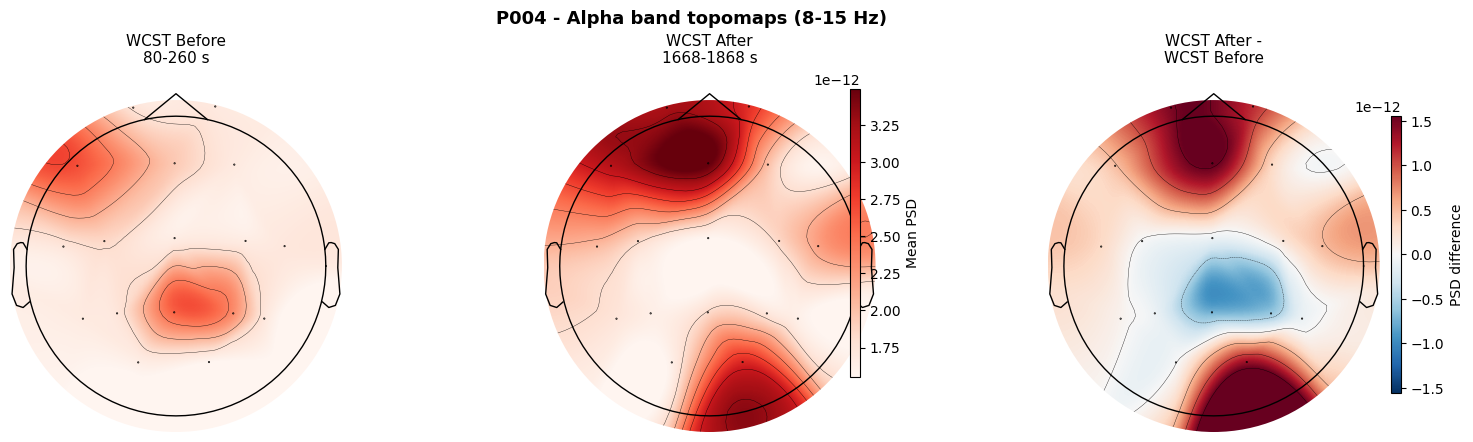

In [214]:
if subject_for_band not in raw_bp_by_subject:
    raise ValueError(f"Missing filtered Raw object for {subject_for_band}")

subject_data = spectrum_results[subject_for_band]
condition_names = list(subject_data.keys())
band_range = freq_bands[selected_band]

raw_topo = raw_bp_by_subject[subject_for_band].copy().pick(
    list(subject_data[condition_names[0]]["ch_names"])
)
info_topo = raw_topo.info.copy()

band_power_maps = {}
for cond_name in condition_names:
    cond_data = subject_data[cond_name]
    freqs = cond_data["freqs"]
    psd_data = cond_data["psd_data"]
    band_mask = (freqs >= band_range[0]) & (freqs <= band_range[1])

    if not np.any(band_mask):
        raise ValueError(
            f"No PSD samples found for {selected_band} band in condition {cond_name}"
        )

    band_power_maps[cond_name] = psd_data[:, band_mask].mean(axis=1)

condition_arrays = [band_power_maps[name] for name in condition_names]
cond_vmin = float(np.min([arr.min() for arr in condition_arrays]))
cond_vmax = float(np.max([arr.max() for arr in condition_arrays]))


def make_band_evoked(values, comment):
    return mne.EvokedArray(
        np.asarray(values, dtype=float)[:, np.newaxis],
        info_topo.copy(),
        tmin=0.0,
        comment=comment,
        nave=1,
    )


show_difference = len(condition_names) >= 2
n_panels = len(condition_names) + (1 if show_difference else 0)
fig_width = 4.8 * n_panels + (1.2 if show_difference else 0.6)
fig, axes = plt.subplots(1, n_panels, figsize=(fig_width, 4.8))
axes = np.atleast_1d(axes)

last_condition_im = None
for ax, cond_name in zip(axes, condition_names):
    evoked = make_band_evoked(band_power_maps[cond_name], cond_name)
    evoked.plot_topomap(
        times=[0.0],
        axes=ax,
        ch_type="eeg",
        colorbar=False,
        time_format="",
        scalings=1,
        vlim=(cond_vmin, cond_vmax),
        show=False,
    )
    last_condition_im = ax.images[0]
    interval = subject_data[cond_name]["interval"]
    ax.set_title(f"{cond_name}\n{interval[0]}-{interval[1]} s", fontsize=11, pad=10)

condition_axes = list(axes[:len(condition_names)])
if last_condition_im is not None:
    fig.colorbar(
        last_condition_im,
        ax=condition_axes,
        shrink=0.78,
        pad=0.035,
        fraction=0.05,
        aspect=28,
        label="Mean PSD",
    )

if show_difference:
    diff_name = f"{condition_names[1]} -\n{condition_names[0]}"
    diff_values = band_power_maps[condition_names[1]] - band_power_maps[condition_names[0]]
    diff_limit = float(np.max(np.abs(diff_values)))
    diff_ax = axes[-1]
    diff_evoked = make_band_evoked(diff_values, diff_name)
    diff_evoked.plot_topomap(
        times=[0.0],
        axes=diff_ax,
        ch_type="eeg",
        colorbar=False,
        time_format="",
        scalings=1,
        cmap="RdBu_r",
        vlim=(-diff_limit, diff_limit),
        show=False,
    )
    diff_im = diff_ax.images[0]
    diff_ax.set_title(diff_name, fontsize=11, pad=10)
    fig.colorbar(
        diff_im,
        ax=diff_ax,
        shrink=0.78,
        pad=0.03,
        fraction=0.05,
        aspect=28,
        label="PSD difference",
    )

fig.suptitle(
    f"{subject_for_band} - {selected_band} band topomaps ({band_range[0]}-{band_range[1]} Hz)",
    fontsize=13,
    fontweight="bold",
    y=0.96,
    )
fig.subplots_adjust(top=0.82, bottom=0.08, left=0.04, right=0.96, wspace=0.45)
plt.show()

## engagement ratios

In [219]:
ratio_type = "beta_over_alpha_theta"

ratio_configs = {
    "beta_over_alpha": {
        "label": "Beta / Alpha",
        "num_band": (16, 30),
        "den_bands": [(8, 15)],
    },
    "beta_over_alpha_theta": {
        "label": "Beta / (Alpha + Theta)",
        "num_band": (16, 30),
        "den_bands": [(8, 15), (4, 7)],
    },
    "1_over_alpha": {
        "label": "1 / Alpha",
        "num_band": None,
        "numerator_constant": 1.0,
        "den_bands": [(8, 15)],
    },
}

if ratio_type not in ratio_configs:
    raise ValueError(f"Invalid ratio_type='{ratio_type}'. Choose one of {list(ratio_configs.keys())}")

cfg = ratio_configs[ratio_type]
ratio_label = cfg["label"]
num_band = cfg.get("num_band", None)
numerator_constant = float(cfg.get("numerator_constant", np.nan))
den_bands = cfg["den_bands"]


def mean_band_power(freqs, psd_values, band_range):
    fmin_b, fmax_b = band_range
    mask = (freqs >= fmin_b) & (freqs <= fmax_b)
    if not np.any(mask):
        return np.nan
    return float(np.mean(psd_values[mask]))


ratio_results = {}
for subj, subj_data in sorted(spectrum_results.items()):
    ratio_results[subj] = {}
    for cond_name, cond_data in subj_data.items():
        freqs = cond_data["freqs"]
        psd_data = cond_data["psd_data"]  # shape: (n_channels, n_freqs)
        ch_names = cond_data["ch_names"]

        ratio_per_channel = []
        for ch_idx in range(psd_data.shape[0]):
            ch_psd = psd_data[ch_idx]

            if num_band is None:
                num_power = numerator_constant
            else:
                num_power = mean_band_power(freqs, ch_psd, num_band)

            den_power = sum(mean_band_power(freqs, ch_psd, b) for b in den_bands)
            ratio_val = num_power / (den_power + 1e-12)
            ratio_per_channel.append(ratio_val)

        ratio_per_channel = np.array(ratio_per_channel, dtype=float)
        ratio_results[subj][cond_name] = {
            "ratio_per_channel": ratio_per_channel,
            "ratio_mean": float(np.nanmean(ratio_per_channel)),
            "ch_names": ch_names,
            "interval": cond_data["interval"],
        }

print(f"Computed ratio type: {ratio_label}")
print(f"Ratios use the electrode subset already stored in Cell 13: {ch_names}")

Computed ratio type: Beta / (Alpha + Theta)
Ratios use the electrode subset already stored in Cell 13: ['P7', 'P4', 'Cz', 'Pz', 'P3', 'P8', 'O1', 'O2', 'T8', 'C4', 'F4', 'Fp2', 'Fz', 'C3', 'Fp1', 'T7', 'F7']


### Participant-level comparison with unified y-scale

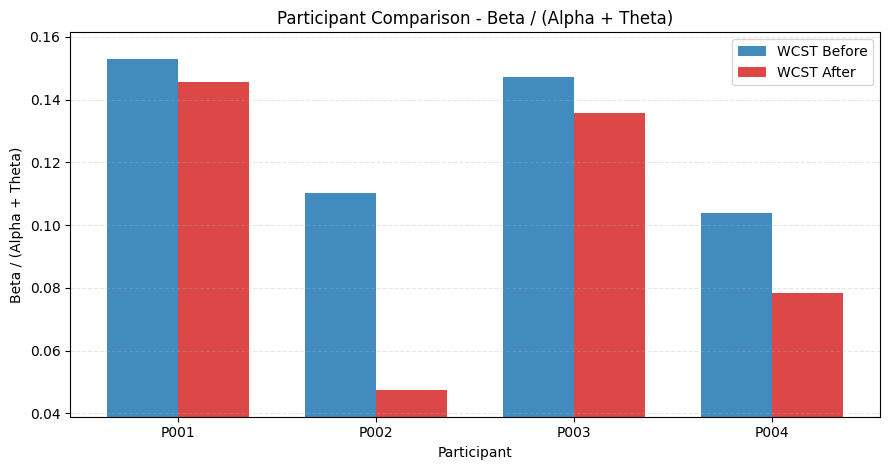

In [220]:
subjects = sorted(ratio_results.keys())
conditions = list(ratio_results[subjects[0]].keys())

participant_values = {
    cond: [ratio_results[subj][cond]["ratio_mean"] for subj in subjects]
    for cond in conditions
}
all_participant_vals = np.array([v for vals in participant_values.values() for v in vals], dtype=float)

p_ymin = float(np.nanmin(all_participant_vals))
p_ymax = float(np.nanmax(all_participant_vals))
p_pad = 0.08 * (p_ymax - p_ymin) if p_ymax > p_ymin else 0.1
p_ylim = (p_ymin - p_pad, p_ymax + p_pad)

x = np.arange(len(subjects))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(9, 4.8))
colors = ["#1f77b4", "#d62728"]
for i, cond in enumerate(conditions):
    x_offset = x + (i - 0.5) * bar_width
    ax.bar(x_offset, participant_values[cond], width=bar_width,
           label=cond, color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(subjects, fontsize=10)
ax.set_ylabel(f"{ratio_label}")
ax.set_xlabel("Participant")
ax.set_title(f"Participant Comparison - {ratio_label}")
ax.set_ylim(p_ylim)  # Unified participant scale
ax.grid(True, axis="y", alpha=0.3, linestyle="--")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


### Electrode-level comparison

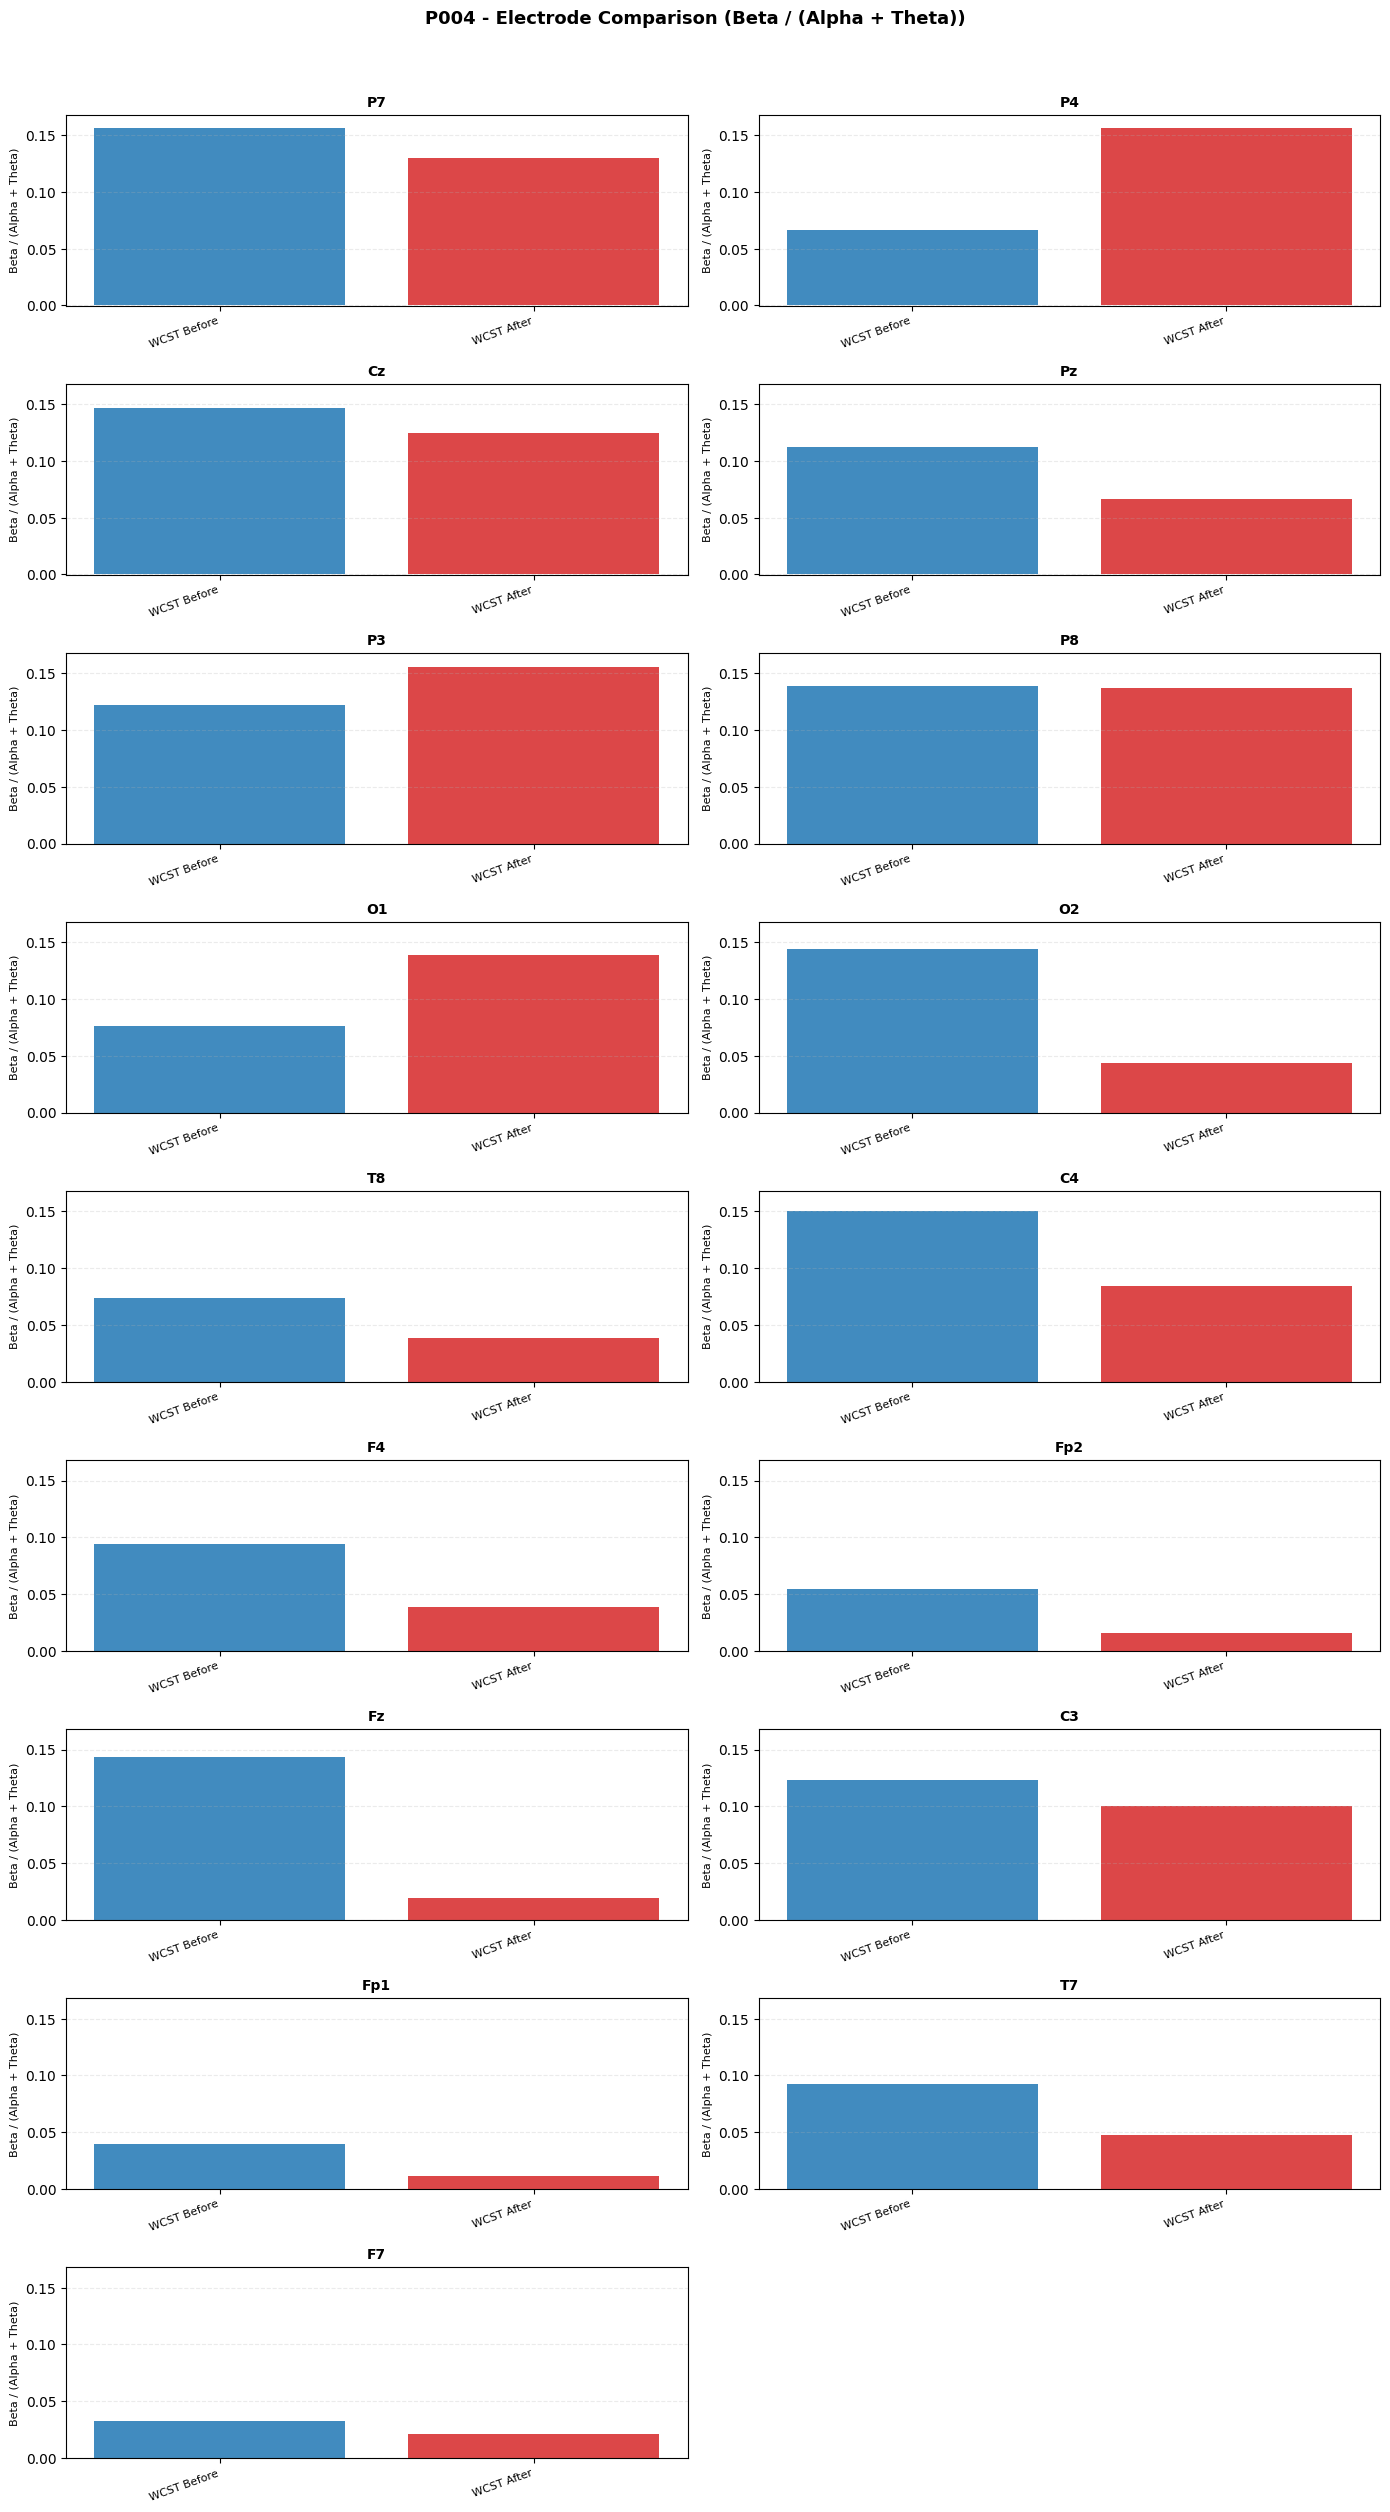

In [221]:
subject_for_ratio_channels = subjects[3]
selected_electrodes_ratio = []

subject_data = ratio_results[subject_for_ratio_channels]
all_ch_names = subject_data[conditions[0]]["ch_names"]

if selected_electrodes_ratio:
    missing_electrodes = [ch for ch in selected_electrodes_ratio if ch not in all_ch_names]
    if missing_electrodes:
        raise ValueError(
            f"These electrodes are not available for {subject_for_ratio_channels}: {missing_electrodes}. "
            f"Available electrodes from Cell 13: {all_ch_names}"
        )
    selected_indices = [all_ch_names.index(ch) for ch in selected_electrodes_ratio]
    ch_names = selected_electrodes_ratio
else:
    selected_indices = list(range(len(all_ch_names)))
    ch_names = all_ch_names

n_channels = len(selected_indices)

all_ch_vals = np.array(
    [
        subject_data[cond]["ratio_per_channel"][ch_idx]
        for cond in conditions
        for ch_idx in selected_indices
    ],
    dtype=float,
)
c_ymin = float(np.nanmin(all_ch_vals))
c_ymax = float(np.nanmax(all_ch_vals))
c_pad = 0.08 * (c_ymax - c_ymin) if c_ymax > c_ymin else 0.1
c_ylim = (c_ymin - c_pad, c_ymax + c_pad)

n_cols = 2
n_rows = (n_channels + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.8 * n_rows))
axes = np.atleast_1d(axes).flatten()

for plot_idx, ch_idx in enumerate(selected_indices):
    ch_name = all_ch_names[ch_idx]
    ax = axes[plot_idx]
    for i, cond in enumerate(conditions):
        ratio_val = subject_data[cond]["ratio_per_channel"][ch_idx]
        ax.bar(i, ratio_val, color=colors[i % len(colors)], alpha=0.85)

    ax.set_title(ch_name, fontsize=10, fontweight="bold")
    ax.set_xticks(range(len(conditions)))
    ax.set_xticklabels(conditions, rotation=20, ha="right", fontsize=8)
    ax.set_ylim(c_ylim)  # Unified electrode scale
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_ylabel(f"{ratio_label}", fontsize=8)

# Remove unused axes
for idx in range(n_channels, len(axes)):
    fig.delaxes(axes[idx])

fig.suptitle(
    f"{subject_for_ratio_channels} - Electrode Comparison ({ratio_label})",
    fontsize=13,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()